In [90]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

import joblib as jb

In [91]:
data=pd.read_csv(r"C:\Projects\football_final\data\epl_final.csv")

In [92]:
data.columns

Index(['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals',
       'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals',
       'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShots', 'AwayShots',
       'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
       'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
       'HomeRedCards', 'AwayRedCards'],
      dtype='str')

In [93]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0


In [94]:
data['MatchDate']=pd.to_datetime(data['MatchDate'])

In [95]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0


In [96]:
data = data.sort_values(by='MatchDate').reset_index(drop=True)

In [97]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0


In [98]:
data['FullTimeResult'] = data['FullTimeResult'].map({
    'H': 0,   # Home Win
    'D': 1,   # Draw
    'A': 2    # Away Win
})

In [99]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,7,2,3,6,10,11,2,2,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,2,5,1,4,15,10,2,1,0,0


In [100]:
data['GoalDiff'] = data['FullTimeHomeGoals'] - data['FullTimeAwayGoals']
data['ShotDiff'] = data['HomeShots'] - data['AwayShots']
data['ShotOnTargetDiff'] = data['HomeShotsOnTarget'] - data['AwayShotsOnTarget']
data['FoulDiff'] = data['HomeFouls'] - data['AwayFouls']
data['YellowDiff'] = data['HomeYellowCards'] - data['AwayYellowCards']
data['RedDiff'] = data['HomeRedCards'] - data['AwayRedCards']
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,1,2,0,0,4,9,10,1,-1,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,1,2,0,0,2,5,5,5,-1,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,5,3,1,0,-2,-10,-6,-6,2,1
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,1,1,0,0,0,-7,-2,-2,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,1,3,0,0,2,5,2,1,-2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,2,2,0,0,0,4,0,3,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,2,2,0,0,2,6,5,-1,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,0,2,0,0,1,-2,1,-2,-2,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,2,1,0,0,0,-8,-3,5,1,0


In [101]:
le = LabelEncoder()

data['HomeTeam_enc'] = le.fit_transform(data['HomeTeam'])
data['AwayTeam_enc'] = le.fit_transform(data['AwayTeam'])

data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeRedCards,AwayRedCards,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff,HomeTeam_enc,AwayTeam_enc
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,0,0,4,9,10,1,-1,0,12,26
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,0,0,2,5,5,5,-1,0,13,43
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,1,0,-2,-10,-6,-6,2,1,14,28
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,0,0,0,-7,-2,-2,0,0,16,36
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,0,0,2,5,2,1,-2,0,22,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,0,0,0,4,0,3,0,0,43,40
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,0,0,2,6,5,-1,0,0,13,24
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,0,0,1,-2,1,-2,-2,0,8,27
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,0,0,0,-8,-3,5,1,0,9,29


In [102]:
model = data[[
    'HomeTeam_enc',
    'AwayTeam_enc',
    'GoalDiff',
    'ShotDiff',
    'ShotOnTargetDiff',
    'FoulDiff',
    'YellowDiff',
    'RedDiff',
    'FullTimeResult'
]]
model

,HomeTeam_enc,AwayTeam_enc,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff,FullTimeResult
0,12,26,4,9,10,1,-1,0,0
1,13,43,2,5,5,5,-1,0,0
2,14,28,-2,-10,-6,-6,2,1,2
3,16,36,0,-7,-2,-2,0,0,1
4,22,17,2,5,2,1,-2,0,0
...,...,...,...,...,...,...,...,...,...
9375,43,40,0,4,0,3,0,0,1
9376,13,24,2,6,5,-1,0,0,0
9377,8,27,1,-2,1,-2,-2,0,0
9378,9,29,0,-8,-3,5,1,0,1


In [103]:
print(model.head())
print(model.isnull().sum())

   HomeTeam_enc  AwayTeam_enc  GoalDiff  ShotDiff  ShotOnTargetDiff  FoulDiff  \
0            12            26         4         9                10         1   
1            13            43         2         5                 5         5   
2            14            28        -2       -10                -6        -6   
3            16            36         0        -7                -2        -2   
4            22            17         2         5                 2         1   

   YellowDiff  RedDiff  FullTimeResult  
0          -1        0               0  
1          -1        0               0  
2           2        1               2  
3           0        0               1  
4          -2        0               0  
HomeTeam_enc        0
AwayTeam_enc        0
GoalDiff            0
ShotDiff            0
ShotOnTargetDiff    0
FoulDiff            0
YellowDiff          0
RedDiff             0
FullTimeResult      0
dtype: int64


In [104]:
team_history = defaultdict(list)

In [105]:
def get_last_n_stats(matches, n=5):
    last_matches = matches[-n:]
    
    wins, draws, losses = 0, 0, 0
    goals_scored, goals_conceded = 0, 0
    
    for m in last_matches:
        goals_scored += m['scored']
        goals_conceded += m['conceded']
        
        if m['result'] == 'W':
            wins += 1
        elif m['result'] == 'D':
            draws += 1
        else:
            losses += 1
    
    total = len(last_matches)
    
    if total == 0:
        return [0]*6
    
    return [
        wins,
        draws,
        losses,
        goals_scored / total,
        goals_conceded / total,
        (wins*3 + draws) / total   # avg points
    ]

In [106]:
elo = defaultdict(lambda: 1500) 
K = 30
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
print(expected_score(1500, 1500))

0.5


In [107]:
features = []

for i, row in data.iterrows():
    
    home = row['HomeTeam']
    away = row['AwayTeam']
    
    # get past stats BEFORE this match
    home_stats = get_last_n_stats(team_history[home])
    away_stats = get_last_n_stats(team_history[away])
    home_elo = elo[home]
    away_elo = elo[away]
    elo_diff = home_elo - away_elo
    features.append(home_stats + away_stats+[home_elo, away_elo, elo_diff])
    
    # ----- NOW update history AFTER computing features -----
    # Home team result
    if row['FullTimeHomeGoals'] > row['FullTimeAwayGoals']:
        home_result = 1
        away_result = 0
        h_res, a_res = 'W', 'L'
        
    elif row['FullTimeHomeGoals'] < row['FullTimeAwayGoals']:
        home_result = 0
        away_result = 1
        h_res, a_res = 'L', 'W'
        
    else:
        home_result = away_result = 0.5
        h_res = a_res = 'D'
    
    expected_home = expected_score(home_elo, away_elo)
    expected_away = expected_score(away_elo, home_elo)
    
    
    elo[home] += K * (home_result - expected_home)
    elo[away] += K * (away_result - expected_away)
    
    # update home team history
    team_history[home].append({
        'scored': row['FullTimeHomeGoals'],
        'conceded': row['FullTimeAwayGoals'],
        'result': home_result
    })
    
    # update away team history
    team_history[away].append({
        'scored': row['FullTimeAwayGoals'],
        'conceded': row['FullTimeHomeGoals'],
        'result': away_result
    })

In [108]:
features

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 1, 0.0, 1.0, 0.0, 0, 0, 1, 1.0, 0.0, 0.0, 1485.0, 1515.0, -30.0],
 [0, 0, 1, 0.0, 1.0, 0.0, 0, 0, 1, 4.0, 2.0, 0.0, 1485.0, 1515.0, -30.0],
 [0, 0, 1, 1.0, 3.0, 0.0, 0, 0, 1, 2.0, 0.0, 0.0, 1485.0, 1515.0, -30.0],
 [0, 0, 1, 3.0, 1.0, 0.0, 0, 0, 1, 3.0, 1.0, 0.0, 1515.0, 1515.0, 0.0],
 [0, 0, 1, 2.0, 4.0, 0.0, 0, 0, 1, 0.0, 0.0, 0.0, 1485.0, 1500.0, -15.0],
 [0, 0, 1, 0.0, 2.0, 0.0, 0, 0, 1, 2.0, 2.0, 0.0, 1485.0, 1500.0, -15.0],
 [0, 0, 1, 2.0, 2.

In [109]:
feature_cols = [
    'home_wins', 'home_draws', 'home_losses',
    'home_avg_scored', 'home_avg_conceded', 'home_avg_points',
    
    'away_wins', 'away_draws', 'away_losses',
    'away_avg_scored', 'away_avg_conceded', 'away_avg_points',
    
    'home_elo', 'away_elo', 'elo_diff'
]

X = pd.DataFrame(features, columns=feature_cols)
Y = data['FullTimeResult']

In [110]:
Y

0       0
1       0
2       2
3       1
4       0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 9380, dtype: int64

In [111]:
X=X.iloc[50:]
Y=Y.iloc[50:]

In [112]:
X

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
50,0,0,4,1.25,0.75,0.0,0,0,5,1.0,1.6,0.0,1512.585649,1472.236955,40.348694
51,0,0,5,1.80,1.60,0.0,0,0,5,2.8,0.6,0.0,1501.107750,1539.549207,-38.441457
52,0,0,5,1.40,1.80,0.0,0,0,5,1.4,0.8,0.0,1471.784388,1529.875050,-58.090662
53,0,0,4,1.00,1.25,0.0,0,0,5,0.6,1.6,0.0,1499.971172,1488.499673,11.471499
54,0,0,5,2.00,1.40,0.0,0,0,5,1.0,1.4,0.0,1514.216801,1501.236608,12.980193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.20,1.80,0.0,0,0,5,1.4,2.6,0.0,1523.788808,1523.865952,-0.077143
9376,0,0,5,1.20,0.60,0.0,0,0,5,2.2,1.0,0.0,1677.684060,1835.617108,-157.933048
9377,0,0,5,1.60,1.00,0.0,0,0,5,0.4,1.4,0.0,1621.041828,1564.014765,57.027063
9378,0,0,5,1.60,2.60,0.0,0,0,5,3.2,1.0,0.0,1609.713603,1694.678778,-84.965175


In [113]:
Y

50      2
51      2
52      0
53      0
54      0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 9330, dtype: int64

In [114]:
X_train = X.loc[data['MatchDate'] < '2021-01-01']
X_test  = X.loc[data['MatchDate'] >= '2021-01-01']

Y_train = Y.loc[data['MatchDate'] < '2021-01-01']
Y_test  = Y.loc[data['MatchDate'] >= '2021-01-01']

In [115]:
X

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
50,0,0,4,1.25,0.75,0.0,0,0,5,1.0,1.6,0.0,1512.585649,1472.236955,40.348694
51,0,0,5,1.80,1.60,0.0,0,0,5,2.8,0.6,0.0,1501.107750,1539.549207,-38.441457
52,0,0,5,1.40,1.80,0.0,0,0,5,1.4,0.8,0.0,1471.784388,1529.875050,-58.090662
53,0,0,4,1.00,1.25,0.0,0,0,5,0.6,1.6,0.0,1499.971172,1488.499673,11.471499
54,0,0,5,2.00,1.40,0.0,0,0,5,1.0,1.4,0.0,1514.216801,1501.236608,12.980193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.20,1.80,0.0,0,0,5,1.4,2.6,0.0,1523.788808,1523.865952,-0.077143
9376,0,0,5,1.20,0.60,0.0,0,0,5,2.2,1.0,0.0,1677.684060,1835.617108,-157.933048
9377,0,0,5,1.60,1.00,0.0,0,0,5,0.4,1.4,0.0,1621.041828,1564.014765,57.027063
9378,0,0,5,1.60,2.60,0.0,0,0,5,3.2,1.0,0.0,1609.713603,1694.678778,-84.965175


In [116]:
X_train

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
50,0,0,4,1.25,0.75,0.0,0,0,5,1.0,1.6,0.0,1512.585649,1472.236955,40.348694
51,0,0,5,1.80,1.60,0.0,0,0,5,2.8,0.6,0.0,1501.107750,1539.549207,-38.441457
52,0,0,5,1.40,1.80,0.0,0,0,5,1.4,0.8,0.0,1471.784388,1529.875050,-58.090662
53,0,0,4,1.00,1.25,0.0,0,0,5,0.6,1.6,0.0,1499.971172,1488.499673,11.471499
54,0,0,5,2.00,1.40,0.0,0,0,5,1.0,1.4,0.0,1514.216801,1501.236608,12.980193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7660,0,0,5,0.80,2.40,0.0,0,0,5,2.0,2.6,0.0,1435.931791,1487.632862,-51.701071
7661,0,0,5,0.80,0.60,0.0,0,0,5,0.8,2.0,0.0,1546.732009,1422.982469,123.749539
7662,0,0,5,1.20,0.60,0.0,0,0,5,1.2,2.0,0.0,1612.056374,1562.531601,49.524773
7663,0,0,5,0.80,1.60,0.0,0,0,5,1.0,1.4,0.0,1498.623532,1579.291974,-80.668442


In [117]:
X_test

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
7665,0,0,5,1.4,0.4,0.0,0,0,5,1.0,1.4,0.0,1627.159523,1564.655393,62.504131
7666,0,0,5,2.4,1.2,0.0,0,0,5,1.6,0.2,0.0,1722.415451,1543.206578,179.208873
7667,0,0,5,0.6,1.4,0.0,0,0,5,0.8,1.2,0.0,1487.045006,1595.815467,-108.770461
7668,0,0,5,0.6,2.4,0.0,0,0,5,1.2,1.0,0.0,1423.147575,1590.870500,-167.722925
7669,0,0,5,1.0,1.2,0.0,0,0,5,2.8,2.0,0.0,1666.346190,1500.417079,165.929112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.2,1.8,0.0,0,0,5,1.4,2.6,0.0,1523.788808,1523.865952,-0.077143
9376,0,0,5,1.2,0.6,0.0,0,0,5,2.2,1.0,0.0,1677.684060,1835.617108,-157.933048
9377,0,0,5,1.6,1.0,0.0,0,0,5,0.4,1.4,0.0,1621.041828,1564.014765,57.027063
9378,0,0,5,1.6,2.6,0.0,0,0,5,3.2,1.0,0.0,1609.713603,1694.678778,-84.965175


In [118]:
Y_train

50      2
51      2
52      0
53      0
54      0
       ..
7660    2
7661    0
7662    1
7663    2
7664    1
Name: FullTimeResult, Length: 7615, dtype: int64

In [119]:
Y_test

7665    2
7666    0
7667    1
7668    2
7669    0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 1715, dtype: int64

In [120]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(7615, 15) (1715, 15)
(7615,) (1715,)


In [121]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
model.fit(X_train, Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [122]:
Y_pred = model.predict(X_test)

In [123]:
Y_pred

array([0, 0, 2, ..., 0, 2, 0], shape=(1715,))

In [124]:
# accuracy matrices

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5405247813411078
[[625  15 113]
 [248   6 135]
 [269   8 296]]
              precision    recall  f1-score   support

           0       0.55      0.83      0.66       753
           1       0.21      0.02      0.03       389
           2       0.54      0.52      0.53       573

    accuracy                           0.54      1715
   macro avg       0.43      0.45      0.41      1715
weighted avg       0.47      0.54      0.47      1715



<Axes: >

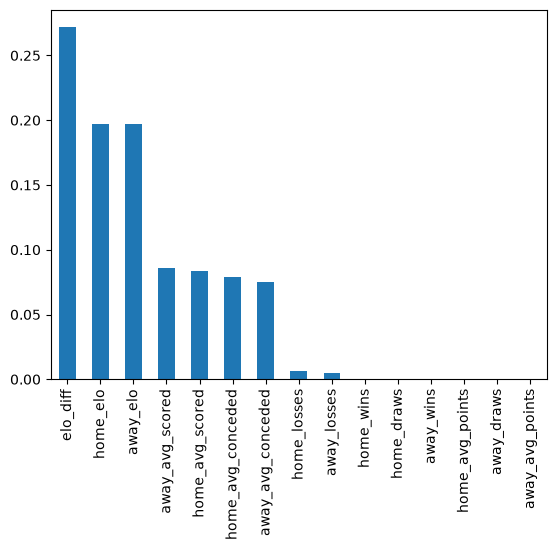

In [125]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')

In [126]:
print(Y.value_counts())

FullTimeResult
0    4275
2    2759
1    2296
Name: count, dtype: int64


In [127]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [128]:
mlp = MLPClassifier(
    max_iter=500,
    early_stopping=True,
    random_state=42
)

param_dist_mlp = {
    'hidden_layer_sizes': [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32)
    ],
    'activation': [
        'relu',
        'tanh'
    ],
    'solver': [
        'adam'
    ],
    'alpha': [
        0.0001,
        0.001,
        0.01,
        0.1
    ],
    'learning_rate_init': [
        0.0005,
        0.001,
        0.005,
        0.01
    ],
    'batch_size': [
        32,
        64,
        128
    ]
}
tscv = TimeSeriesSplit(n_splits=5)
search_mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist_mlp,
    n_iter=30,
    scoring='accuracy',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)
scaler_cv = StandardScaler()

X_scaled = scaler_cv.fit_transform(X)
search_mlp.fit(
    X_scaled,
    Y
)
mlp = search_mlp.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [129]:
mlp.fit(X_train_scaled, Y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.1
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.005
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divid

In [130]:
Y_pred = mlp.predict(X_test_scaled)

In [131]:
Y_pred

array([0, 0, 0, ..., 0, 2, 0], shape=(1715,))

In [132]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5422740524781341
[[642   0 111]
 [263   0 126]
 [285   0 288]]
              precision    recall  f1-score   support

           0       0.54      0.85      0.66       753
           1       0.00      0.00      0.00       389
           2       0.55      0.50      0.52       573

    accuracy                           0.54      1715
   macro avg       0.36      0.45      0.40      1715
weighted avg       0.42      0.54      0.47      1715



c:\Projects\football_final\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projects\football_final\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projects\football_final\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [133]:
accuracy_nn = accuracy_score(Y_test, Y_pred)

In [134]:
model.predict(X_test)

array([0, 0, 2, ..., 0, 2, 0], shape=(1715,))

In [135]:
Y_pred = model.predict(X_test)


In [136]:
Y_prob = model.predict_proba(X_test)

In [137]:
Y_prob

array([[0.52677754, 0.30052053, 0.17270193],
       [0.72572102, 0.16682472, 0.10745426],
       [0.31842499, 0.32203302, 0.35954199],
       ...,
       [0.58731039, 0.22416442, 0.18852519],
       [0.30848736, 0.29591535, 0.39559729],
       [0.40726091, 0.31573388, 0.27700521]], shape=(1715, 3))

In [138]:
y_home = data['FullTimeHomeGoals']
y_away = data['FullTimeAwayGoals']

y_home = data['FullTimeHomeGoals'].iloc[50:]
y_away = data['FullTimeAwayGoals'].iloc[50:]

y_home_train = y_home.loc[X_train.index]
y_home_test  = y_home.loc[X_test.index]

y_away_train = y_away.loc[X_train.index]
y_away_test  = y_away.loc[X_test.index]



In [139]:
mlp_reg = MLPRegressor(
    max_iter=500,
    early_stopping=True,
    random_state=42
)

param_dist_mlp_reg = {
    'hidden_layer_sizes': [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32)
    ],
    'activation': [
        'relu',
        'tanh'
    ],
    'solver': [
        'adam'
    ],
    'alpha': [
        0.0001,
        0.001,
        0.01,
        0.1
    ],
    'learning_rate_init': [
        0.0005,
        0.001,
        0.005,
        0.01
    ],
    'batch_size': [
        32,
        64,
        128
    ]
}

search_home_mlp = RandomizedSearchCV(
    estimator=mlp_reg,
    param_distributions=param_dist_mlp_reg,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_away_mlp = RandomizedSearchCV(
    estimator=mlp_reg,
    param_distributions=param_dist_mlp_reg,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_home_mlp.fit(X_scaled,y_home)
search_away_mlp.fit(X_scaled,y_away)

home_goal_mlp = search_home_mlp.best_estimator_

home_goal_mlp.fit(
    X_train_scaled,
    y_home_train
)

away_goal_mlp = search_home_mlp.best_estimator_

away_goal_mlp.fit(
    X_train_scaled,
    y_away_train
)

home_pred = home_goal_mlp.predict(
    X_test_scaled
)

print(
    "Home Goal MAE:",
    mean_absolute_error(
        y_home_test,
        home_pred
    )
)

away_pred = away_goal_mlp.predict(
    X_test_scaled
)

print(
    "Away Goal MAE:",
    mean_absolute_error(
        y_away_test,
        away_pred
    )
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Home Goal MAE: 1.2083973858123749
Away Goal MAE: 0.903901459131072


In [140]:
mae = [mean_absolute_error(y_home_test, home_pred), mean_absolute_error(y_away_test, away_pred)]

In [141]:
def create_match_features_elo(home_team, away_team):

    home_stats = get_last_n_stats(
        team_history[home_team]
    )

    away_stats = get_last_n_stats(
        team_history[away_team]
    )

    home_elo = elo[home_team] + 100
    away_elo = elo[away_team]

    elo_diff = home_elo - away_elo

    features = (
        home_stats
        + away_stats
        + [home_elo, away_elo, elo_diff]
    )

    return pd.DataFrame(
        [features],
        columns=feature_cols
    )

def predict_match_mlp(home_team, away_team):

    features = create_match_features_elo(
        home_team,
        away_team
    )

    features_scaled = scaler.transform(features)

    probs = mlp.predict_proba(
        features_scaled
    )[0]

    pred = mlp.predict(
        features_scaled
    )[0]

    outcome_map = {
        0: "Home Win",
        1: "Draw",
        2: "Away Win"
    }

    home_goals = home_goal_mlp.predict(
        features_scaled
    )[0]

    away_goals = away_goal_mlp.predict(
        features_scaled
    )[0]

    score_home = max(0, round(home_goals))
    score_away = max(0, round(away_goals))

    print(f"\n{home_team} vs {away_team}")

    print("\nWin Probabilities")
    print(f"Home Win : {probs[0]*100:.2f}%")
    print(f"Draw     : {probs[1]*100:.2f}%")
    print(f"Away Win : {probs[2]*100:.2f}%")

    print("\nPredicted Outcome")
    print(outcome_map[pred])

    print("\nExpected Goals")
    print(f"{home_team}: {home_goals:.2f}")
    print(f"{away_team}: {away_goals:.2f}")

    print(
        f"\nPredicted Score: "
        f"{score_home}-{score_away}"
    )
    
print(predict_match_mlp("Arsenal","Man City"))


Arsenal vs Man City

Win Probabilities
Home Win : 66.85%
Draw     : 19.62%
Away Win : 13.53%

Predicted Outcome
Home Win

Expected Goals
Arsenal: 0.89
Man City: 0.89

Predicted Score: 1-1
None


In [142]:
def predict_match_mlp_st(home_team, away_team):
    features_st = create_match_features_elo(
        home_team,
        away_team
    )

    features_scaled_st = scaler.transform(features_st)

    probs_st = mlp.predict_proba(
        features_scaled_st
    )[0]

    home_win_prob_st = round(probs_st[0], 2)
    draw_prob_st = round(probs_st[1], 2)
    away_win_prob_st = round(probs_st[2], 2)

    home_goals_st = home_goal_mlp.predict(
        features_scaled_st
    )[0]

    away_goals_st = away_goal_mlp.predict(
        features_scaled_st
    )[0]

    predicted_home_st = max(0, round(home_goals_st))
    predicted_away_st = max(0, round(away_goals_st))

    return[
        home_win_prob_st,
        draw_prob_st,
        away_win_prob_st,
        predicted_home_st,
        predicted_away_st
    ]

In [143]:
jb.dump(scaler, r"C:\Projects\football_final\training\dumped_models_vars\nn_scaler.joblib")

jb.dump(model, r"C:\Projects\football_final\training\dumped_models_vars\nn_model.joblib")
jb.dump(home_goal_mlp, r"C:\Projects\football_final\training\dumped_models_vars\nn_home_goal.joblib")
jb.dump(away_goal_mlp, r"C:\Projects\football_final\training\dumped_models_vars\nn_away_goal.joblib")

jb.dump(accuracy_nn, r"C:\Projects\football_final\training\dumped_models_vars\nn_acc.joblib")

['C:\\Projects\\football_final\\training\\dumped_models_vars\\nn_acc.joblib']

In [144]:
jb.dump(mae, r"C:\Projects\football_final\training\dumped_models_vars\mae_nn.joblib")

['C:\\Projects\\football_final\\training\\dumped_models_vars\\mae_nn.joblib']